In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

# Cấu hình để hiển thị biểu đồ lớn và rõ nét
%matplotlib inline
plt.rcParams['figure.figsize'] = [15, 12]

In [3]:
def get_grayscale_image(img_path):
    """
    Đọc ảnh và chuyển sang ảnh xám theo nguyên lý Rec. 601 (Chuẩn ITU-R BT.601)
    L = 0.299*R + 0.587*G + 0.114*B
    """
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        return None, None
    
    # Chuyển đổi sang RGB để tách kênh chính xác
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    R, G, B = img_rgb[:, :, 0], img_rgb[:, :, 1], img_rgb[:, :, 2]
    
    # Chuyển đổi thủ công để nắm giữ bản chất xử lý ảnh màu
    img_gray = (0.299 * R + 0.587 * G + 0.114 * B).astype(np.uint8)
    return img_rgb, img_gray

def apply_low_pass_filters(img_gray):
    """
    Thực hiện Low-pass filtering: Mean Filter và Gaussian Filter.
    Mục tiêu: Làm trơn ảnh và giảm nhiễu.
    """
    # 1. Mean Filter (Kernel 5x5)
    mean_blur = cv2.blur(img_gray, (5, 5))
    
    # 2. Gaussian Filter (sigma = 1.2)
    gauss_blur = cv2.GaussianBlur(img_gray, (0, 0), sigmaX=1.2)
    
    return mean_blur, gauss_blur

def calculate_metrics(original, filtered):
    """Tính toán các chỉ số định lượng MSE, PSNR và Sharpness (Laplacian Variance)"""
    mse = np.mean((original.astype(np.float32) - filtered.astype(np.float32)) ** 2)
    psnr = cv2.PSNR(original, filtered)
    # Phương sai Laplacian dùng để đo lượng chi tiết/biên (Sharpness) còn lại
    sharpness = cv2.Laplacian(filtered, cv2.CV_64F).var()
    return round(mse, 2), round(psnr, 2), round(sharpness, 2)

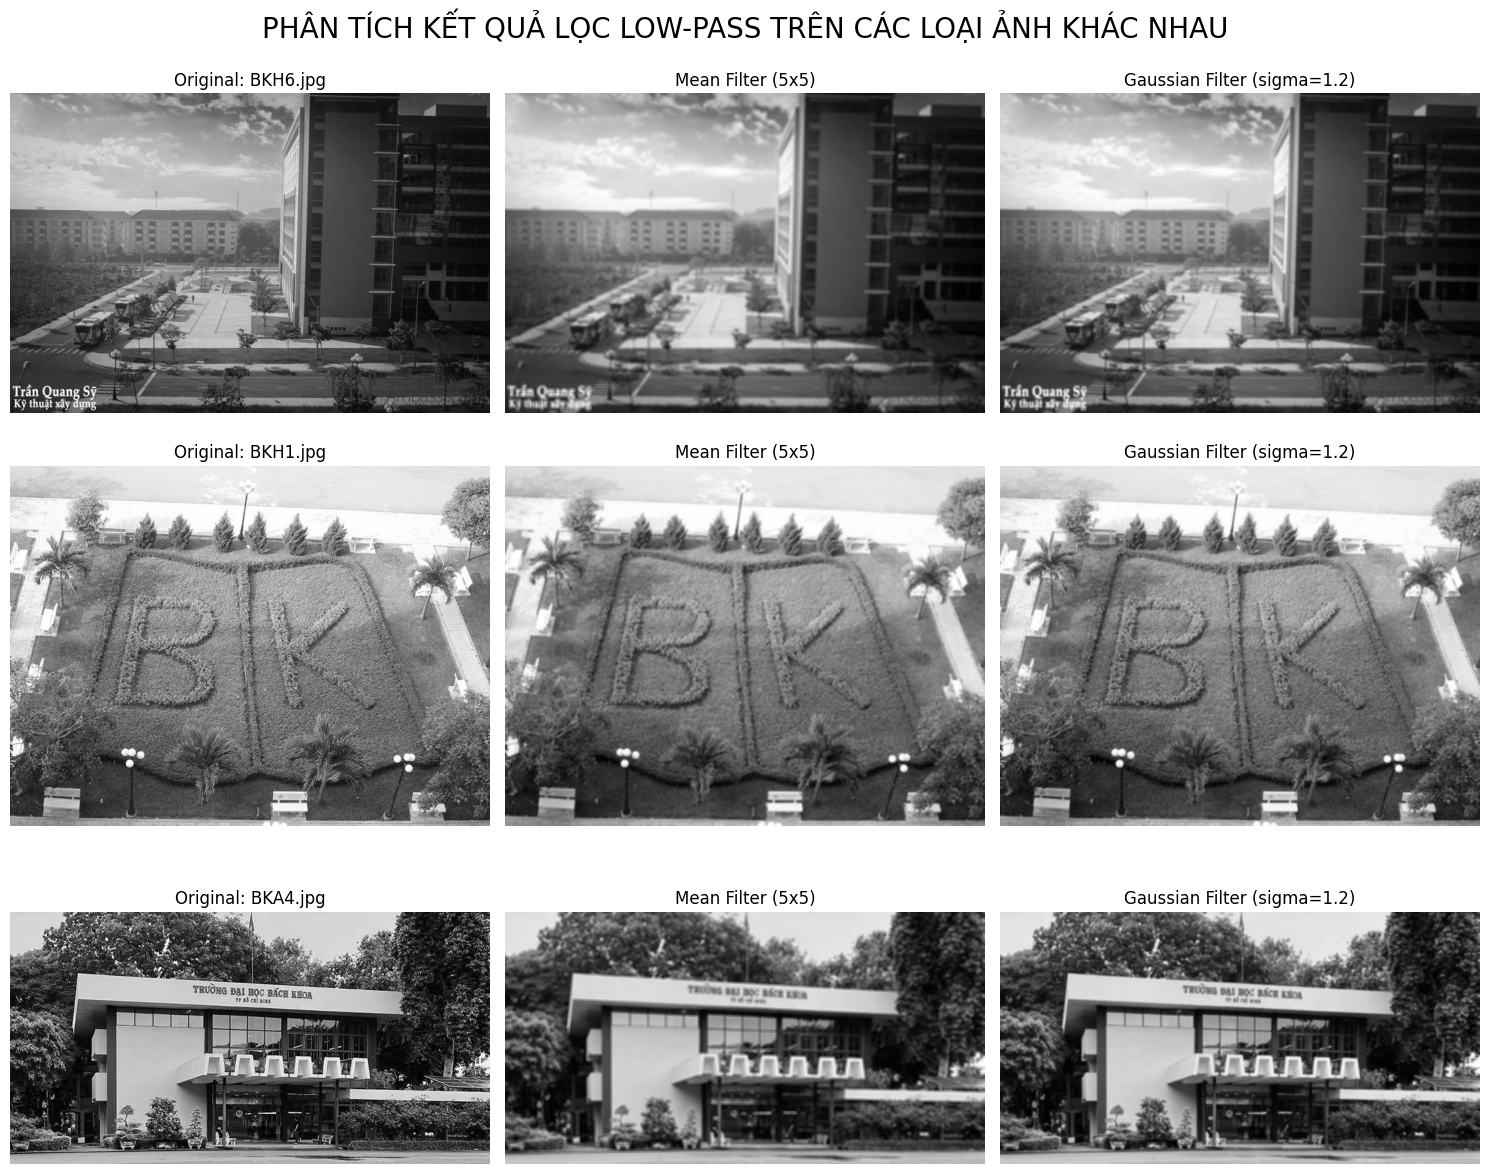

In [4]:
# Cấu hình đường dẫn ảnh theo yêu cầu của bạn
image_paths = [
    "sample/BKH6.jpg",
    "sample/BKH1.jpg",
    "sample/BKA4.jpg",
]

results_data = []

# Tạo khung hình 3 hàng x 3 cột
fig, axes = plt.subplots(nrows=len(image_paths), ncols=3)

for i, path in enumerate(image_paths):
    # Bước 1: Load và chuyển đổi ảnh xám
    img_rgb, img_gray = get_grayscale_image(path)
    file_name = os.path.basename(path)
    
    if img_gray is not None:
        # Bước 2: Áp dụng các bộ lọc Low-pass
        mean_res, gauss_res = apply_low_pass_filters(img_gray)
        
        # Bước 3: Tính toán chỉ số đánh giá định lượng
        _, _, orig_sharp = calculate_metrics(img_gray, img_gray)
        
        # Số liệu cho Mean Filter
        m_mse, m_psnr, m_sharp = calculate_metrics(img_gray, mean_res)
        m_loss = round((1 - m_sharp/orig_sharp)*100, 2)
        results_data.append({'Image': file_name, 'Filter': 'Mean 5x5', 'MSE': m_mse, 'PSNR': m_psnr, 'Sharpness Loss (%)': m_loss})
        
        # Số liệu cho Gaussian Filter
        g_mse, g_psnr, g_sharp = calculate_metrics(img_gray, gauss_res)
        g_loss = round((1 - g_sharp/orig_sharp)*100, 2)
        results_data.append({'Image': file_name, 'Filter': 'Gaussian 1.2', 'MSE': g_mse, 'PSNR': g_psnr, 'Sharpness Loss (%)': g_loss})

        # Bước 4: Hiển thị trực quan (So sánh 3 cột)
        axes[i, 0].imshow(img_gray, cmap='gray')
        axes[i, 0].set_title(f"Original: {file_name}")
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(mean_res, cmap='gray')
        axes[i, 1].set_title("Mean Filter (5x5)")
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(gauss_res, cmap='gray')
        axes[i, 2].set_title("Gaussian Filter (sigma=1.2)")
        axes[i, 2].axis('off')
    else:
        print(f"Lỗi: Không tìm thấy ảnh tại {path}")

plt.tight_layout()
plt.suptitle("PHÂN TÍCH KẾT QUẢ LỌC LOW-PASS TRÊN CÁC LOẠI ẢNH KHÁC NHAU", fontsize=20, y=1.03)
plt.show()

In [6]:
# Hiển thị bảng số liệu định lượng
df = pd.DataFrame(results_data)
print("\n--- BẢNG ĐÁNH GIÁ ĐỊNH LƯỢNG LOW-PASS FILTER ---")
display(df)


--- BẢNG ĐÁNH GIÁ ĐỊNH LƯỢNG LOW-PASS FILTER ---


,Image,Filter,MSE,PSNR,Sharpness Loss (%)
0,BKH6.jpg,Mean 5x5,133.410004,26.88,97.22
1,BKH6.jpg,Gaussian 1.2,79.779999,29.11,96.17
2,BKH1.jpg,Mean 5x5,301.529999,23.34,98.78
3,BKH1.jpg,Gaussian 1.2,204.229996,25.03,98.15
4,BKA4.jpg,Mean 5x5,828.950012,18.95,98.56
5,BKA4.jpg,Gaussian 1.2,549.140015,20.73,98.24


In [8]:
# Ghi chú cho báo cáo
print("\nNHẬN XÉT ĐỊNH LƯỢNG:")
print("- PSNR: Gaussian Filter thường có PSNR cao hơn, cho thấy độ trung thực tốt hơn.")
print("- Sharpness Loss: Tỷ lệ mất độ sắc nét cao ở ảnh nhiều chi tiết (BKH1) và ảnh nhiễu (BKA4).")


NHẬN XÉT ĐỊNH LƯỢNG:
- PSNR: Gaussian Filter thường có PSNR cao hơn, cho thấy độ trung thực tốt hơn.
- Sharpness Loss: Tỷ lệ mất độ sắc nét cao ở ảnh nhiều chi tiết (BKH1) và ảnh nhiễu (BKA4).
